# IFN680 Project 5 - LLMForward

**Group 4** - Karan Rooprai (n12498122), Nhu Hieu Nguyen (n12194778)

This notebook extends the Week 7 addition model to **subtraction**, including negative results, and trains it in **Forward mode**: the answer is predicted left to right.

The tokeniser, architecture, causal next-token objective and training loop follow the Week 7 workshop. `REVERSE` below is the only switch that separates this notebook from its counterpart, which is what makes output direction the single variable in the comparison.

In [1]:
# The one line that differs between the two training
# notebooks. It selects the target digit order, and
# nothing else in either file depends on the mode.
REVERSE = False

## Setup

In [2]:
# Same stack as the Week 7 workshop, plus json for the machine readable result dumps.
import json
import math
import os
import pickle
import random
import re
import time


import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F

# The brief asks for the GPU environment. The model still runs on CPU when no GPU is visible,
# so the notebook runs unchanged on a machine without one and gives the same answers.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device : {device}")
print(f"torch  : {torch.__version__}")
print(f"numpy  : {np.__version__}")

# Every result quoted in the report is reproducible from this seed alone, including the
# train/validation/test split, which is regenerated and checked further down.
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
# Bound to _ because manual_seed returns the Generator it just seeded, and a bare call as the
# last line of a cell would store that object's repr as an output.
_ = torch.manual_seed(SEED)

device : cuda
torch  : 2.13.0+cu126
numpy  : 2.5.3


## Step 1: Tokenizer

In [3]:
# The workshop's vocabulary plus one "-" token. That token does double duty: it is the
# subtraction operator inside a prompt ("50-73=") and the negative sign inside a result ("-23").
# Reusing one symbol keeps the vocabulary at 15 and lets position carry the distinction, which
# is something the attention mechanism can learn and an extra token would have hidden.
pad_token = "[PAD]"
eos_token = "[EOS]"


class character_level_tokenizer:
    def __init__(self):
        self.vocab = [str(x) for x in range(10)] + ["+", "-", "="] + [pad_token, eos_token]
        self.token_to_id = {v: k for k, v in enumerate(self.vocab)}
        self.id_to_token = {k: v for k, v in enumerate(self.vocab)}
        self.ntokens = len(self.vocab)
        # Anything outside the vocabulary is stripped rather than mapped to an unknown token,
        # because every string this model ever sees is generated, not typed by a person.
        self.pattern = f"[^{re.escape(''.join(self.vocab))}]"

    def clean(self, text):
        return re.sub(self.pattern, "", text)

    def pre_tokenization(self, text):
        return [character for character in text]

    def encode(self, text):
        return [self.token_to_id[c] for c in self.pre_tokenization(self.clean(text))]

    def decode(self, token_list):
        return "".join([self.id_to_token[i] for i in token_list])


tokenizer = character_level_tokenizer()
ntokens = tokenizer.ntokens
print(f"ntokens: {ntokens} | vocab: {tokenizer.vocab}")

ntokens: 15 | vocab: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '+', '-', '=', '[PAD]', '[EOS]']


## Step 2: Data for addition and subtraction

Operands are non-negative and at most three digits; a subtraction may be negative when `b > a`. Prompts of the form `-2+3` are out of scope, so no operand ever carries a sign.

In [4]:
def build_dataset(train_size, val_size, test_size, number_digits=3, seed=SEED):
    """Unique, non-overlapping splits with a balanced 50/50 addition and subtraction mix.

    Uniqueness is enforced per operation on the prompt string, then the two streams are
    interleaved and shuffled once before being sliced. Slicing a single shuffled list is what
    makes the three splits disjoint by construction rather than by a later check.
    """
    rng = random.Random(seed)
    total = train_size + val_size + test_size
    per_op = total // 2 + 1

    def unique_for(operation, n):
        seen, out, hi = set(), [], 10 ** number_digits
        while len(out) < n:
            a_int, b_int = rng.randint(0, hi - 1), rng.randint(0, hi - 1)
            prompt = f"{a_int}{operation}{b_int}="
            if prompt in seen:
                continue
            seen.add(prompt)
            # str() of a negative int already carries the leading "-", so the target needs no
            # special casing for b > a.
            result = a_int + b_int if operation == "+" else a_int - b_int
            out.append((prompt, str(result)))
        return out

    additions, subtractions = unique_for("+", per_op), unique_for("-", per_op)
    mixed = []
    for pair_add, pair_sub in zip(additions, subtractions):
        mixed += [pair_add, pair_sub]
    rng.shuffle(mixed)
    return (mixed[:train_size],
            mixed[train_size:train_size + val_size],
            mixed[train_size + val_size:train_size + val_size + test_size])

### Reverse-order transform, parsing, and carry or borrow structure

In [5]:
# Reverse mode reverses the whole answer string literally, so "31" becomes "13" and the units
# digit is emitted first. For a negative result "-123" becomes "321-": the sign lands last,
# which is consistent with right-to-left arithmetic because the sign of a difference is only
# known once the magnitude has been worked out. The brief does not prescribe a rule here, so
# this is a choice, and reversing the string literally is the choice that needs no extra logic.
def to_reverse(text):
    return text[::-1]


def from_reverse(text):
    return text[::-1]


def parse_answer(answer_string, reverse=False):
    """Turn a decoded answer back into an int, un-reversing first when in reverse mode."""
    text = from_reverse(answer_string) if reverse else answer_string
    negative = text.startswith("-")
    digits = "".join(c for c in text if c.isdigit())
    if digits == "":
        return None  # the model emitted no digit at all; counted as an error, never as a zero
    return -int(digits) if negative else int(digits)


def operation_of(prompt):
    return "+" if "+" in prompt else "-"


def carry_positions(a_int, b_int):
    """Units-first flags marking each column of a + b that produces a carry."""
    width = max(len(str(a_int)), len(str(b_int)), len(str(a_int + b_int)))
    left, right = str(a_int).zfill(width), str(b_int).zfill(width)
    carry, flags = 0, []
    for i in reversed(range(width)):
        flags.append(carry)
        carry = 1 if int(left[i]) + int(right[i]) + carry >= 10 else 0
    return flags


def borrow_positions(a_int, b_int):
    """Units-first flags marking each column of a - b that requires a borrow.

    Borrowing is a property of the magnitudes, so the larger operand is put on top first. That
    makes 12-99 and 99-12 share a borrow structure, which is what the arithmetic actually does.
    """
    hi, lo = (a_int, b_int) if a_int >= b_int else (b_int, a_int)
    width = max(len(str(hi)), len(str(lo)))
    top, bottom = str(hi).zfill(width), str(lo).zfill(width)
    borrow, flags = 0, []
    for i in reversed(range(width)):
        upper, lower = int(top[i]) - borrow, int(bottom[i])
        flags.append(1 if upper < lower else 0)
        borrow = 1 if upper < lower else 0
    return flags

## Step 3: Positional encoding

Self-attention sees a set of tokens, not a sequence, so position has to be added to the embedding before the model can tell `12+3` from `21+3`. The fixed sinusoidal encoding of the workshop is kept unchanged. Note what it encodes: where a digit sits in the string, not what place value it holds. Those two coincide for the forward ordering and not for the reverse one.

In [6]:
class PositionalEncoding(nn.Module):
    """Sinusoidal absolute positional encoding, exactly as the workshop defines it.

    Absolute rather than relative positions matter for this project: in reverse mode the model
    has to associate "the position 0 token" with the units digit of an answer whose length it
    has not yet committed to, and that is the comparison Task 2 is asking about.
    """

    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp((torch.arange(0, d_model, 2).float() / d_model) * (-math.log(1e4)))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        # Stored as (max_len, 1, d_model) to match the (sequence, batch, feature) layout the
        # rest of the notebook uses, and registered as a buffer so it moves with .to(device).
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)

## Step 4: Transformer model

A causal decoder. Each position may attend only to positions at or before it, which is what makes it safe to train on every position of a sequence at once: no position can reach the answer it is being asked to predict.

In [7]:
class CustomEncoderLayer(nn.TransformerEncoderLayer):
    """The workshop's encoder layer, which keeps its attention weights for inspection."""

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.attn_weights = None

    def forward(self, src, src_mask=None, src_key_padding_mask=None, **kwargs):
        src2, attn_weights = self.self_attn(
            src, src, src, attn_mask=src_mask, key_padding_mask=src_key_padding_mask,
            need_weights=True, average_attn_weights=False)
        self.attn_weights = attn_weights
        src = self.norm1(src + self.dropout1(src2))
        src2 = self.linear2(self.dropout(self.activation(self.linear1(src))))
        return self.norm2(src + self.dropout2(src2))


class TransformerModel(nn.Module):
    def __init__(self, ntoken, ninp, nhead, nhid, nlayers, dropout=0.1):
        super().__init__()
        self.input_emb = nn.Embedding(ntoken, ninp)
        self.pos_encoder = PositionalEncoding(ninp, dropout)
        encoder_layers = CustomEncoderLayer(ninp, nhead, nhid, dropout)
        # enable_nested_tensor is switched off explicitly. This model runs with
        # batch_first=False, so the nested-tensor fast path is unusable anyway and PyTorch
        # would otherwise emit a UserWarning on every construction.
        self.encoder = nn.TransformerEncoder(encoder_layers, nlayers, enable_nested_tensor=False)
        self.decoder = nn.Linear(ninp, ntoken)
        self.ninp = ninp
        self.init_weights()

    def init_weights(self):
        initrange = 0.1
        nn.init.uniform_(self.input_emb.weight, -initrange, initrange)
        nn.init.zeros_(self.decoder.bias)
        nn.init.uniform_(self.decoder.weight, -initrange, initrange)

    def _generate_square_subsequent_mask(self, size):
        # log of a lower-triangular matrix of ones: 0 where attention is allowed, -inf above the
        # diagonal. Adding it to the attention scores is what makes the model causal.
        return torch.log(torch.tril(torch.ones(size, size)))

    def forward(self, src):
        mask = self._generate_square_subsequent_mask(len(src)).to(src.device)
        src = self.input_emb(src) * math.sqrt(self.ninp)
        src = self.pos_encoder(src)
        output_enc = self.encoder(src, mask=mask)
        output_dec = self.decoder(output_enc)
        attention_maps = [layer.attn_weights for layer in self.encoder.layers]
        return F.log_softmax(output_dec, dim=-1), output_enc, attention_maps

## Step 5: Generation, padding and batching

Prompts differ in length, so they are padded to a common width before being stacked into a batch. Decoding takes the arg max at every step instead of sampling, which makes a prediction a function of the weights alone and the whole evaluation repeatable.

In [8]:
# Three utilities the workshop keeps separate: decoding, padding, and assembling a batch.
# Each takes the model or the data as an argument, so the same code serves training and
# evaluation and nothing here reads a global.
def generate(model, prompts, new_tokens=6):
    """Greedy autoregressive decoding: append the arg max token, then feed it back in.

    Greedy rather than sampled, so decoding is deterministic: re-running this notebook on
    different hardware gives the same predictions.
    """
    input_tensor = prompts.to(device)
    for _ in range(new_tokens):
        output, _, _ = model(input_tensor)
        token = torch.argmax(output[-1, :, :], -1).view((1, -1))
        input_tensor = torch.cat((input_tensor, token), 0)
    return input_tensor


def pad(token_list, type_list="prompts"):
    """Prompts are left-padded, answers are right-padded after an [EOS].

    Left-padding the prompts keeps the "=" in the same relative place as the generation start,
    so the first predicted token always follows the equals sign whatever the operand widths.
    """
    max_length = max(len(x) for x in token_list)
    out = []
    for x in token_list:
        if type_list == "prompts":
            out.append([tokenizer.token_to_id[pad_token]] * (max_length - len(x)) + x)
        else:
            out.append(x + [tokenizer.token_to_id[eos_token]] +
                       [tokenizer.token_to_id[pad_token]] * (max_length - len(x)))
    return out, max_length


def get_batch(data, i, batch_size, reverse):
    """One batch of (prompt, answer) pairs. `reverse` decides the target's digit order only."""
    j_end = min(i + batch_size, len(data))
    prompts = [tokenizer.encode(data[j][0]) for j in range(i, j_end)]
    padded_prompts, length_prompts = pad(prompts, "prompts")
    answers = [tokenizer.encode(to_reverse(data[j][1]) if reverse else data[j][1])
               for j in range(i, j_end)]
    padded_answers, length_answers = pad(answers, "answers")
    X = torch.stack([torch.tensor(x) for x in padded_prompts], 1)
    Y = torch.stack([torch.tensor(x) for x in padded_answers], 1)
    return X, Y, length_prompts, length_answers

## Step 6: Accuracy metrics

Two levels, because they answer different questions. Digit accuracy counts individual characters and shows how close a wrong answer was; sequence accuracy demands the entire answer and is the one the task is scored on. Sequence accuracy is always the lower of the two, and the gap between them is a measure of how near the misses are.

In [9]:
# Two views of accuracy. evaluate() is the workshop's token-level measure, used to watch
# convergence while training; predict_numeric() decodes to integers, which is what Task 3
# scores, because whether the sum is right is a question about the number not the tokens.
def evaluate(model, input_data, reverse, batch_size=200):
    """Token-level and whole-sequence accuracy, as defined in the workshop.

    The model is passed in rather than read from the enclosing scope, so the same function can
    score the trained model and the ablation model without either of them being a global.
    """
    model.eval()
    correct_digit = total_digit = correct = total = 0.0
    with torch.no_grad():
        for i in range(0, len(input_data), batch_size):
            prompts, targets, length_prompts, length_answers = get_batch(
                input_data, i, batch_size, reverse)
            prompts, targets = prompts.to(device), targets.to(device)
            output = generate(model, prompts, length_answers + 1)
            answers_tokens = output[length_prompts:, :]
            target_mask_pad = targets != tokenizer.token_to_id[pad_token]
            equality_test = answers_tokens == targets
            correct_digit += torch.logical_and(target_mask_pad, equality_test).sum().item()
            total_digit += target_mask_pad.sum().item()
            correct += torch.all(torch.logical_or(~target_mask_pad, equality_test),
                                 axis=0).float().sum().item()
            total += targets.shape[-1]
    return correct_digit / total_digit, correct / total


def predict_numeric(model, input_data, reverse, batch_size=200, new_tokens=6):
    """Decode each prompt to an int. Returns (prompts, true ints, predicted ints).

    A prediction that cannot be parsed stays None rather than becoming 0, so an unparseable
    output is never silently scored as a correct answer to "a - a =".
    """
    model.eval()
    prompts_out, trues, preds = [], [], []
    with torch.no_grad():
        for i in range(0, len(input_data), batch_size):
            chunk = input_data[i:i + batch_size]
            encoded = [tokenizer.encode(p) for p, _ in chunk]
            padded, length_prompts = pad(encoded, "prompts")
            X = torch.stack([torch.tensor(x) for x in padded], 1).to(device)
            generated = generate(model, X, new_tokens)[length_prompts:, :]
            for b, (prompt, target) in enumerate(chunk):
                text = tokenizer.decode(generated[:, b].tolist())
                text = text.split(eos_token)[0].replace(pad_token, "")
                prompts_out.append(prompt)
                trues.append(int(target))
                preds.append(parse_answer(text, reverse=reverse))
    return prompts_out, trues, preds

## Build the split, and check it is disjoint

In [10]:
# The same split feeds both models, so the comparison in main_report.ipynb is between two
# training directions rather than between two datasets.
train_size, val_size, test_size = 150000, 10000, 10000
data_train, data_val, data_test = build_dataset(train_size, val_size, test_size)

# The held-out set is written once and then reused. Whichever notebook runs first creates it;
# the other loads it, which is what guarantees both models are scored on identical examples.
if not os.path.exists("project5_testset.pkl"):
    with open("project5_testset.pkl", "wb") as handle:
        pickle.dump(data_test, handle)
    print("wrote project5_testset.pkl")
else:
    with open("project5_testset.pkl", "rb") as handle:
        data_test = pickle.load(handle)
    print("loaded the shared project5_testset.pkl")

# Slicing one shuffled list already guarantees the three splits are disjoint. The assertion
# below restates that guarantee as something the reader can watch pass, because a held-out
# score means nothing if a test prompt was also trained on.
train_prompts = {p for p, _ in data_train} | {p for p, _ in data_val}
overlap = sum(1 for p, _ in data_test if p in train_prompts)
assert overlap == 0, f"{overlap} test prompts also appear in train or validation"
assert len(data_test) >= 10000, "the brief asks for a held-out set of at least 10k samples"

n_sub = sum(1 for p, _ in data_test if "-" in p)
print(f"train {len(data_train)}  val {len(data_val)}  test {len(data_test)}")
print(f"test subtraction fraction {n_sub / len(data_test):.2f}")
print(f"train/test prompt overlap {overlap}")
print(f"examples: {data_train[:4]}")

loaded the shared project5_testset.pkl
train 150000  val 10000  test 10000
test subtraction fraction 0.49
train/test prompt overlap 0
examples: [('73-286=', '-213'), ('630-544=', '86'), ('497+343=', '840'), ('779+580=', '1359')]


## Step 7: Train the Forward model

In [11]:
learning_rate = 1e-3
epochs = 30
batch_size = 100

# dropout 0.1 rather than the class default of 0.5: the workshop's own encoder layer uses 0.1,
# and the add-and-subtract task needs the capacity. The cosine schedule anneals the learning
# rate to near zero by the last epoch, which is what settles the final digit accuracy.
torch.manual_seed(SEED)
model = TransformerModel(ntoken=ntokens, ninp=128, nhead=16, nhid=64, nlayers=6, dropout=0.1)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")


def train_epoch(model, optimizer, data, reverse, batch_size=100):
    """One pass of next-token prediction over `data`. Cross-entropy on the answer tokens only.

    Everything the function needs is an argument, so the identical code trains the main model
    and the reduced-data ablation model further down without either touching a global.
    """
    model.train()
    total_loss, n_batch = 0.0, 0
    for i in range(0, len(data) - 1, batch_size):
        n_batch += 1
        prompts, targets, length_prompts, _ = get_batch(data, i, batch_size, reverse)
        prompts, targets = prompts.to(device), targets.to(device)
        # Prompt and answer are concatenated into one causal sequence; the loss is taken only
        # over the positions that predict answer tokens, which is the slice below.
        input_tensor = torch.cat((prompts, targets), 0)
        optimizer.zero_grad()
        output, _, _ = model(input_tensor)
        output_answers = output[length_prompts - 1:-1, :, :].reshape(-1, ntokens)
        loss = F.cross_entropy(output_answers, targets.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / n_batch

parameters: 502,671


In [12]:
# Validation runs every epoch, which is what turns training into a curve that can be read for
# convergence instead of a single final number. Training accuracy is measured on a fixed subset
# because scoring the full training set every epoch would cost more than the epoch itself.
history = {"loss": [], "val_digit": [], "val_seq": [], "train_seq": []}
started = time.time()
for epoch in range(1, epochs + 1):
    epoch_start = time.time()
    loss = train_epoch(model, optimizer, data_train, REVERSE, batch_size)
    scheduler.step()
    val_digit, val_seq = evaluate(model, data_val, REVERSE)
    _, train_seq = evaluate(model, data_train[:5000], REVERSE)
    history["loss"].append(loss)
    history["val_digit"].append(val_digit)
    history["val_seq"].append(val_seq)
    history["train_seq"].append(train_seq)
    print(f"epoch {epoch:2d} ({time.time() - epoch_start:5.1f}s)  loss {loss:.4f}  "
          f"val digit {val_digit:.4f}  val seq {val_seq:.4f}  train seq {train_seq:.4f}")
print(f"total training time: {(time.time() - started) / 60:.1f} min")

epoch  1 ( 33.7s)  loss 1.1658  val digit 0.5454  val seq 0.0092  train seq 0.0114


epoch  2 ( 33.6s)  loss 1.0091  val digit 0.6006  val seq 0.0255  train seq 0.0218


epoch  3 ( 33.4s)  loss 0.7539  val digit 0.7406  val seq 0.0838  train seq 0.0742


epoch  4 ( 33.5s)  loss 0.6265  val digit 0.7726  val seq 0.0979  train seq 0.0900


epoch  5 ( 33.4s)  loss 0.5749  val digit 0.7915  val seq 0.1270  train seq 0.1204


...

epoch 26 ( 33.5s)  loss 0.0086  val digit 0.9998  val seq 0.9990  train seq 0.9998


epoch 27 ( 33.5s)  loss 0.0079  val digit 0.9999  val seq 0.9996  train seq 1.0000


epoch 28 ( 33.5s)  loss 0.0071  val digit 0.9999  val seq 0.9995  train seq 1.0000


epoch 29 ( 33.5s)  loss 0.0069  val digit 1.0000  val seq 0.9998  train seq 1.0000


epoch 30 ( 33.5s)  loss 0.0063  val digit 0.9999  val seq 0.9997  train seq 1.0000
total training time: 16.8 min


In [13]:
# The checkpoint is what main_report.ipynb loads; the history is what lets it draw the learning
# curves without containing a training loop, which the brief forbids there.
torch.save(model.state_dict(), "LLMForward.pth")
with open("LLMForward_history.json", "w") as handle:
    json.dump(history, handle)
print(f"saved LLMForward.pth and LLMForward_history.json")

saved LLMForward.pth and LLMForward_history.json


### How much data does this direction need?

Final accuracy and ease of training are different questions. The run below repeats the training above on a smaller slice of the same data, so the two curves can be compared in `main_report.ipynb`.

In [14]:
# Does prediction direction change how much DATA the task needs, as opposed to how accurate the
# final model is? The only way to answer that is to train the same architecture on less data and
# compare the curves, so this repeats the run above on the first 80000 training examples
# and saves its history. It deliberately does not overwrite the checkpoint: this model exists to
# be plotted, not to be scored.
torch.manual_seed(SEED)
model_small = TransformerModel(ntoken=ntokens, ninp=128, nhead=16, nhid=64, nlayers=6, dropout=0.1)
model_small.to(device)
optimizer_small = torch.optim.AdamW(model_small.parameters(), lr=learning_rate)
scheduler_small = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_small, T_max=epochs)

data_small = data_train[:80000]
history_small = {"loss": [], "val_digit": [], "val_seq": [], "train_seq": []}
started = time.time()
for epoch in range(1, epochs + 1):
    loss = train_epoch(model_small, optimizer_small, data_small, REVERSE, batch_size)
    scheduler_small.step()
    val_digit, val_seq = evaluate(model_small, data_val, REVERSE)
    history_small["loss"].append(loss)
    history_small["val_digit"].append(val_digit)
    history_small["val_seq"].append(val_seq)
    # The full run records training accuracy on a fixed probe subset; the ablation skips that
    # measurement to keep the two runs equal in cost per epoch. NaN keeps the four history
    # lists the same length without drawing a line matplotlib would otherwise interpolate.
    history_small["train_seq"].append(float("nan"))
    print(f"epoch {epoch:2d}  loss {loss:.4f}  val digit {val_digit:.4f}  val seq {val_seq:.4f}")
print(f"ablation on {len(data_small)} examples finished in {(time.time() - started) / 60:.1f} min")

with open("LLMForward_history_80k.json", "w") as handle:
    json.dump(history_small, handle)
print(f"saved LLMForward_history_80k.json")

epoch  1  loss 1.2547  val digit 0.5306  val seq 0.0097


epoch  2  loss 1.0612  val digit 0.5460  val seq 0.0100


epoch  3  loss 1.0248  val digit 0.5579  val seq 0.0128


epoch  4  loss 0.9644  val digit 0.6436  val seq 0.0402


epoch  5  loss 0.7552  val digit 0.7185  val seq 0.0623


...

epoch 26  loss 0.0336  val digit 0.9984  val seq 0.9929


epoch 27  loss 0.0327  val digit 0.9986  val seq 0.9939


epoch 28  loss 0.0310  val digit 0.9987  val seq 0.9947


epoch 29  loss 0.0295  val digit 0.9987  val seq 0.9945


epoch 30  loss 0.0285  val digit 0.9987  val seq 0.9945
ablation on 80000 examples finished in 9.1 min
saved LLMForward_history_80k.json


### Learning curves

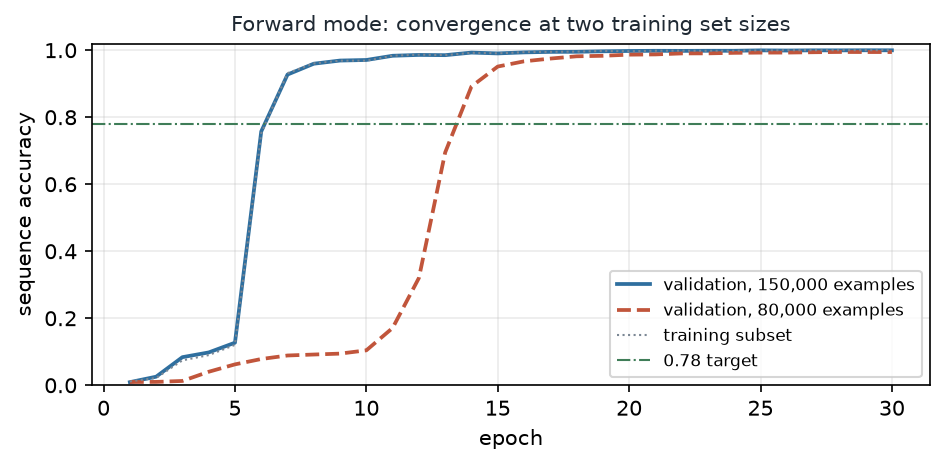

In [15]:
INK, ACCENT, WARM = "#1f2933", "#2f6f9f", "#c1553b"
MUTED, PALE, GREEN = "#7b8794", "#e8ecf1", "#3f7d58"

# Both runs on one axis: the full training set solid, the reduced one dashed. The 0.78 line is
# the level the brief asks the finished model to clear.
fig, ax = plt.subplots(figsize=(6.4, 3.2), dpi=150)
epochs_axis = range(1, len(history["val_seq"]) + 1)
ax.plot(epochs_axis, history["val_seq"], color=ACCENT, lw=1.8,
        label=f"validation, {len(data_train):,} examples")
ax.plot(epochs_axis, history_small["val_seq"], color=WARM, lw=1.8, ls="--",
        label=f"validation, {len(data_small):,} examples")
ax.plot(epochs_axis, history["train_seq"], color=MUTED, lw=1.0, ls=":", label="training subset")
ax.axhline(0.78, color=GREEN, lw=1.0, ls="-.", label="0.78 target")
ax.set_xlabel("epoch")
ax.set_ylabel("sequence accuracy")
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="lower right")
ax.set_title("Forward mode: convergence at two training set sizes", fontsize=10, color=INK)
plt.tight_layout()
plt.show()

### Worked examples and the held-out score

In [16]:
# A dozen worked examples, printed so the notebook shows what the model actually does rather
# than only what it scores. The held-out numbers here are the ones main_report.ipynb reproduces.
_, _, sample_preds = predict_numeric(model, data_test[:12], REVERSE)
print(f"{'prompt':>12} | {'true':>7} | {'predicted':>9}")
for (prompt, target), predicted in zip(data_test[:12], sample_preds):
    print(f"{prompt:>12} | {target:>7} | {str(predicted):>9}")

test_digit, test_seq = evaluate(model, data_test, REVERSE)
print(f"\nheld-out test: digit accuracy {test_digit:.4f} | sequence accuracy {test_seq:.4f}")

      prompt |    true | predicted
    334+511= |     845 |       845
     50+849= |     899 |       899
    952+886= |    1838 |      1838
     175-66= |     109 |       109
    928+204= |    1132 |      1132
    887+553= |    1440 |      1440
    208-711= |    -503 |      -503
     845+32= |     877 |       877
     730-85= |     645 |       645
    616+453= |    1069 |      1069
    760-481= |     279 |       279
    170+304= |     474 |       474



held-out test: digit accuracy 0.9998 | sequence accuracy 0.9993
